Visualizing Data

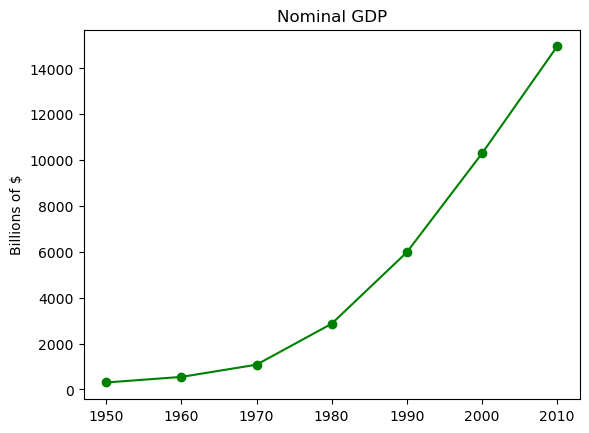

In [18]:
from matplotlib import pyplot as plt
from statsmodels.distributions import edgeworth

years = [1950, 1960, 1970, 1980, 1990, 2000, 2010]
gdp = [300.2, 543.3, 1075.9, 2862.5, 5979.6, 10289.7, 14958.3]

# Create a line chart
plt.plot(years, gdp, color='green', marker='o', linestyle='solid')

plt.title("Nominal GDP")
plt.ylabel("Billions of $")
plt.show()

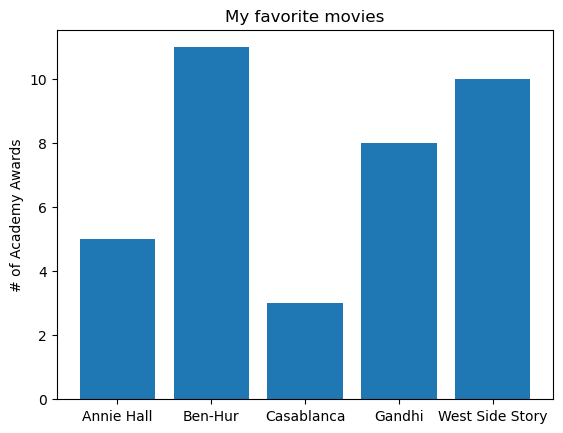

In [19]:
movies = ["Annie Hall", "Ben-Hur", "Casablanca", "Gandhi", "West Side Story"]
num_oscars = [5, 11, 3, 8, 10]

plt.bar(range(len(movies)), num_oscars)

plt.title("My favorite movies")
plt.ylabel("# of Academy Awards")
plt.xticks(range(len(movies)), movies)

plt.show()

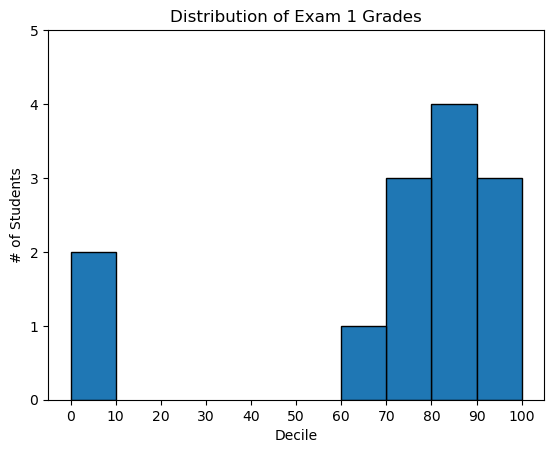

In [24]:
from collections import Counter

grades = [83, 95, 91, 87, 70, 0, 85, 82, 100, 67, 73, 77, 0]

histogram = Counter(min(grade // 10 * 10, 90) for grade in grades)

plt.bar([x + 5 for x in histogram.keys()], histogram.values(), 10, edgecolor=(0, 0, 0))

plt.axis((-5, 105, 0, 5))

plt.xticks([10 * i for i in range(11)])

plt.xlabel("Decile")
plt.ylabel("# of Students")
plt.title("Distribution of Exam 1 Grades")
plt.show()

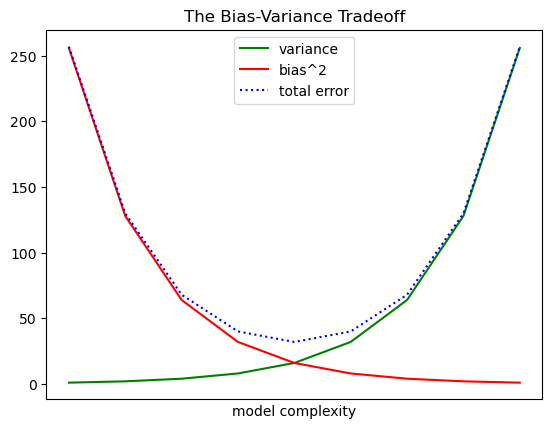

In [25]:
variance = [1, 2, 4, 8, 16, 32, 64, 128, 256]
bias_squared = [256, 128, 64, 32, 16, 8, 4, 2, 1]
total_error = [x + y for x, y in zip(bias_squared, variance)]
xs = [i for i, _ in enumerate(variance)]

plt.plot(xs, variance, 'g-', label='variance')
plt.plot(xs, bias_squared, 'r-', label='bias^2')
plt.plot(xs, total_error, 'b:', label='total error')

plt.legend(loc=9)
plt.xlabel("model complexity")
plt.xticks([])
plt.title("The Bias-Variance Tradeoff")
plt.show()

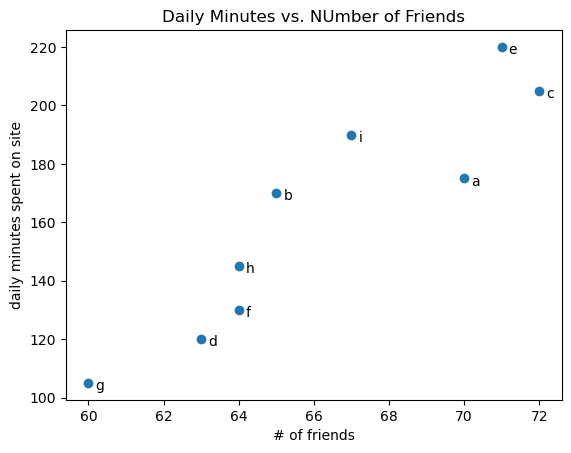

In [31]:
friends = [ 70, 65, 72, 63, 71, 64, 60, 64, 67]
minutes = [175, 170, 205, 120, 220, 130, 105, 145, 190]
labels = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i']

plt.scatter(friends, minutes)

for label, friend_count, minute_count in zip(labels, friends, minutes):
    plt.annotate(label, xy=(friend_count, minute_count), xytext=(5, -5), textcoords='offset points')

plt.title("Daily Minutes vs. NUmber of Friends")
plt.xlabel("# of friends")
plt.ylabel("daily minutes spent on site")
plt.show()

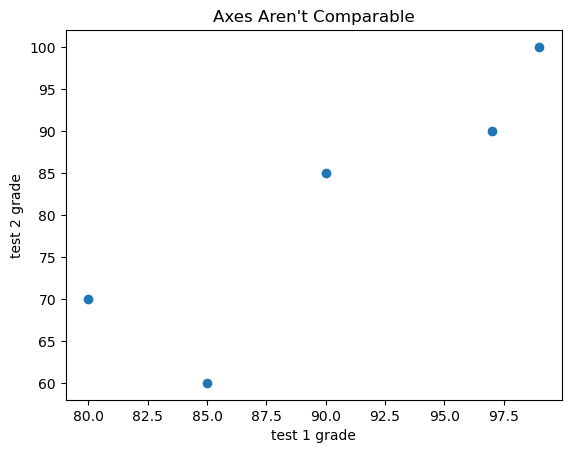

In [32]:
test_1_grades = [ 99, 90, 85, 97, 80]
test_2_grades = [100, 85, 60, 90, 70]

plt.scatter(test_1_grades, test_2_grades)
plt.title("Axes Aren't Comparable")
plt.xlabel("test 1 grade")
plt.ylabel("test 2 grade")
plt.show()

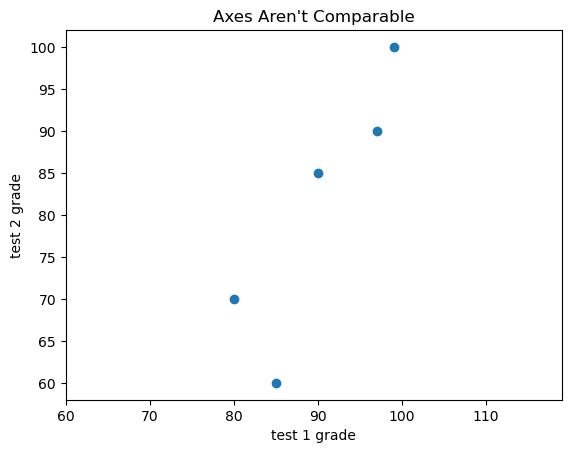

In [34]:
plt.scatter(test_1_grades, test_2_grades)
plt.title("Axes Aren't Comparable")
plt.xlabel("test 1 grade")
plt.ylabel("test 2 grade")
plt.axis("equal")
plt.show()

## ÁLGEBRA LINEAL

In [9]:
from typing import List
import math

Vectors

In [12]:
Vector = List[float]

def add(v: Vector, w: Vector) -> Vector:
    if len(v) != len(w):
        raise ValueError("Vectors must have the same length")
    return [v_i + w_i for v_i, w_i in zip(v, w)]

def subtract(v: Vector, w: Vector) -> Vector:
    if len(v) != len(w):
        raise ValueError("Vectors must have the same length")
    return [v_i - w_i for v_i, w_i in zip(v, w)]

def vector_sum(vectors: List[Vector]) -> Vector:
    if not vectors:
        raise ValueError("No vectors provided")

    num_elements = len(vectors[0])
    if not all(len(v) == num_elements for v in vectors):
        raise ValueError("Vectors must have the same length")

    return [sum(vector[i] for vector in vectors) for i in range(num_elements)]

def scalar_multiply(c: float, v: Vector) -> Vector:
    return [c * v_i for v_i in v]

def vector_mean(vectors: List[Vector]) -> Vector:
    n = len(vectors)
    return scalar_multiply(1/n, vector_sum(vectors))

def dot(v: Vector, w: Vector) -> float:
    if not len(v) == len(w):
        raise ValueError("Vectors must have the same length")
    return sum(v_i * w_i for v_i, w_i in zip(v, w))

def sum_squares(v: Vector) -> float:
     return dot(v, v)

def magnitude(v: Vector) -> float:
    return math.sqrt(sum_squares(v))

def squared_distance(v: Vector, w: Vector) -> float:
    return sum_squares(subtract(v, w))

def distance(v: Vector, w: Vector) -> float:
    return math.sqrt(squared_distance(v, w))

Matrices

In [13]:
from typing import Tuple
from typing import Callable

Matrix = List[List[float]]

def shape(a: Matrix) -> Tuple[int, int]:
    num_rows = len(a)
    num_cols = len(a[0]) if a else 0
    return num_rows, num_cols

def get_rows(a: Matrix, i: int) -> Vector:
    return a[i]

def get_columns(a: Matrix, j: int) -> Vector:
    return [a_i[j] for a_i in a]

def make_matrix(num_rows: int, num_cols: int, entry_fn: Callable[[int, int], float]) -> Matrix:
    return [[entry_fn(i, j) for j in range(num_cols)] for i in range(num_rows)]

def identity_matrix(n: int) -> Matrix:
    return make_matrix(n, n, lambda i, j: 1 if i == j else 0)

Statistics

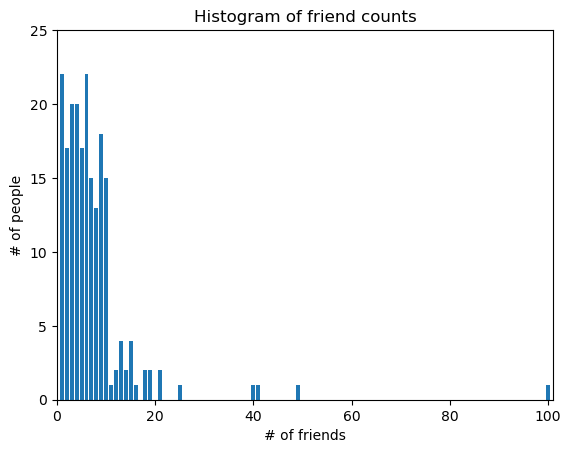

In [21]:
from collections import Counter
import matplotlib.pyplot as plt

num_friends = [100.0,49,41,40,25,21,21,19,19,18,18,16,15,15,15,15,14,14,13,13,13,13,12,12,11,10,10,10,10,10,10,10,10,10,10,10,10,10,10,10,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,9,8,8,8,8,8,8,8,8,8,8,8,8,8,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,6,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1]

friend_counts = Counter(num_friends)
xs = range(101)
ys = [friend_counts[x] for x in xs]

plt.bar(xs, ys)
plt.axis((0, 101, 0, 25))
plt.title("Histogram of friend counts")
plt.xlabel("# of friends")
plt.ylabel("# of people")
plt.show()

In [24]:
print(num_points := len(num_friends))
print(largest_values := max(num_friends))
print(smallest_values := min(num_friends))
sorted_values = sorted(num_friends)
print("\n",sorted_values[0])
print(sorted_values[1])
print(sorted_values[-1])
print(sorted_values[-2])

204
100.0
1

 1
1
100.0
49


Central tendencies

In [33]:
def mean(xs: List[float]) -> float:
    return sum(xs) / len(xs)

def _median_odd(xs: List[float]) -> float:
    return sorted(xs)[len(xs) // 2]

def _median_even(xs: List[float]) -> float:
    sorted_xs = sorted(xs)
    hi_midpoint = len(xs) // 2
    return (sorted_xs[hi_midpoint - 1] + sorted_xs[hi_midpoint]) / 2

def median(v: List[float]) -> float:
    return _median_even(v) if len(v) % 2 == 0 else _median_odd(v)

def quantile(xs: List[float], p: float) -> float:
    p_index = int(p * len(xs))
    return sorted(xs)[p_index]

In [34]:
print(quantile(num_friends, 0.25))

3
